# 🇪🇹 Ethiopia Climate Data Analysis (2015–2026)

## Objective
Analyze temperature, rainfall, and climate variability trends in Ethiopia using NASA POWER dataset.

Focus on:
- Data cleaning
- Seasonal patterns
- Extreme weather events
- Climate insights for COP32 preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading

I load the NASA POWER dataset and inspect structure, columns, and basic integrity.

In [7]:
data = pd.read_csv("../Data/ethiopia.csv")
print(data.head(10))
data.columns

   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  11.73    22.75     3.44      19.31         0.00  41.79  2.73   
1  2015    2  12.30    24.01     4.09      19.92         0.00  33.29  2.39   
2  2015    3  12.49    24.17     3.97      20.20         0.00  33.83  1.77   
3  2015    4  14.08    23.78     6.90      16.88         0.00  38.84  0.87   
4  2015    5  14.06    23.15     7.32      15.83         0.00  47.07  1.34   
5  2015    6  14.26    23.45     7.44      16.01         0.00  58.20  1.70   
6  2015    7  14.37    23.78     6.16      17.62         0.00  59.83  1.99   
7  2015    8  14.18    24.17     6.12      18.05         0.00  57.82  2.25   
8  2015    9  13.89    23.76     5.47      18.29         0.00  58.65  1.97   
9  2015   10  14.25    22.48     7.72      14.76         0.04  53.11  1.93   

   WS2M_MAX     PS  QV2M  
0      5.07  77.13  4.00  
1      4.19  77.14  3.35  
2      2.76  77.11  3.43  
3      1.28  77.07  4.60  
4     

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M'],
      dtype='object')

In [8]:
print(data.shape)
print(data.info())

(4108, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.3 KB
None


## 2. Data Cleaning

I handle missing values, convert date formats, and remove duplicates.

NASA uses -999 as missing values, which we convert to NaN.

In [16]:
data.replace(-999, np.nan, inplace=True)
print(data.isna().sum())
print(data.describe())
print(data.min())

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Month          0
dtype: int64
              YEAR          DOY         T2M      T2M_MAX      T2M_MIN  \
count  4108.000000  4108.000000  4108.00000  4108.000000  4108.000000   
mean   2020.131451   180.121227    16.06850    23.199175    10.227544   
std       3.248907   106.294767     1.89805     2.751471     2.607256   
min    2015.000000     1.000000    10.03000    15.650000     1.170000   
25%    2017.000000    86.000000    14.82000    21.110000     8.417500   
50%    2020.000000   179.000000    16.04000    22.740000    10.990000   
75%    2023.000000   272.000000    17.36000    25.170000    12.220000   
max    2026.000000   366.000000    21.53000    30.930000    15.680000   

         T2M_RANGE  PRECTOTCORR         RH2M         WS2M     WS2M_MAX  \
count  4108.000000  4108.000000  4

## 3. Date Processing

I convert YEAR and DOY into a proper datetime column for time-series analysis.

In [15]:
data["Month"] = pd.to_datetime(data["YEAR"].astype(str) + "-" + data["DOY"].astype(str), format="%Y-%j").dt.month

monthly_temp = data.groupby("Month")["T2M"].mean()
duplicates = data.duplicated().sum()
print("Duplicates:", duplicates)
data = data.drop_duplicates()
missing = data.isna().mean() * 100
print(missing)

Duplicates: 0
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Month          0.0
dtype: float64


In [17]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(data[cols].apply(zscore))
outliers = (z_scores > 3).sum()

print(outliers)

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


## 4. Temperature Trends

I analyze monthly average temperature to identify seasonal patterns and warming trends.

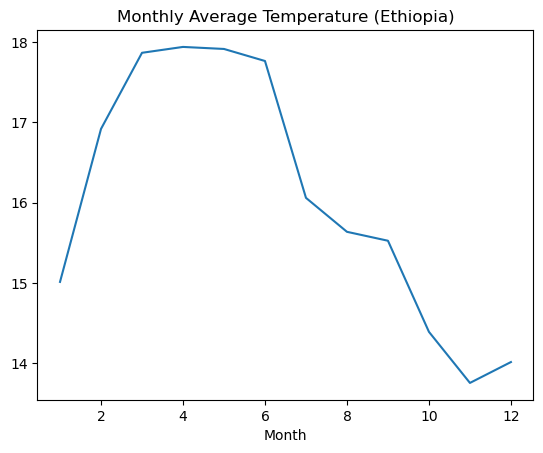

In [12]:
monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature (Ethiopia)")
plt.show()

## 5. Rainfall Patterns

I examine precipitation distribution to understand wet and dry seasons.

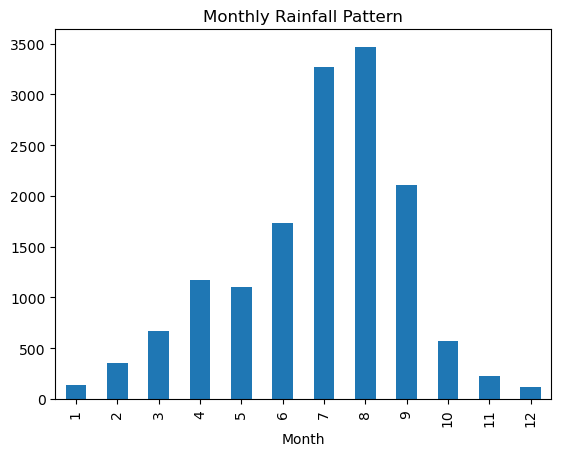

In [13]:
monthly_rain = data.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall Pattern")
plt.show()

## 6. Climate Variable Relationships

I examine correlations between temperature, rainfall, humidity, and wind.

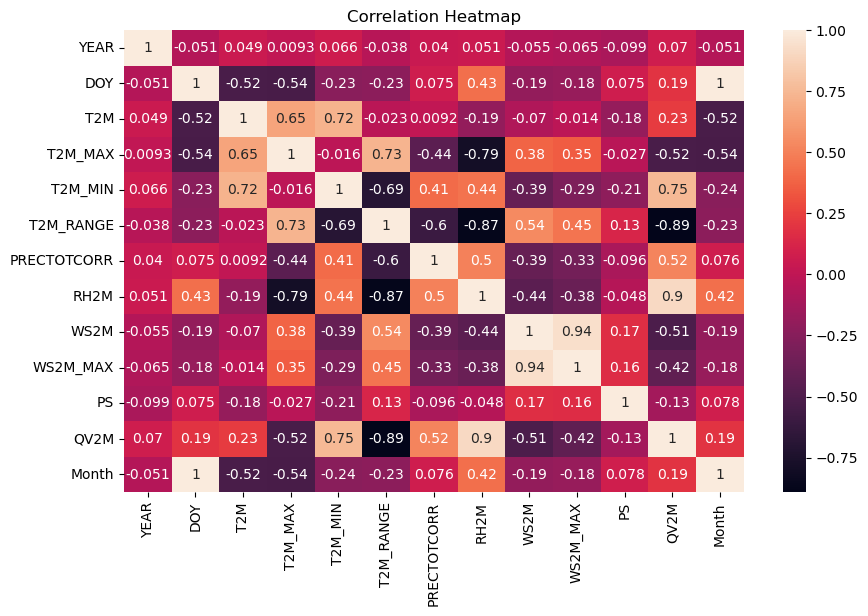

In [14]:

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()